# 5단계 · 실전 확장

이 노트북에서는 실전에 가까운 고급 기능을 배웁니다.

## 학습 목표
1. 멀티 자산 동시 백테스팅
2. 포트폴리오 비중 최적화 (균등 비중 vs 리스크 패리티 vs 변동성 역비례)
3. 자산 모멘텀 로테이션 전략
4. 나만의 전략 모듈 라이브러리로 구조화

---
## 단계별 복습 요약

| 단계 | 내용 |
|-----|------|
| 2단계 | vectorbt 기본 구조, Portfolio.from_signals() |
| 3단계 | MA골든크로스·RSI·MACD 전략 구현 |
| 4단계 | 성과 분석, 그리드서치, IS/OOS 검증 |
| **5단계** | **멀티 자산, 비중 최적화, 모멘텀 로테이션** |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import vectorbt as vbt
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print(f'vectorbt: {vbt.__version__}')
print(f'pandas  : {pd.__version__}')

vectorbt: 0.26.2
pandas  : 1.5.3


---
## 1. 멀티 자산 데이터 로드

여러 자산을 동시에 백테스팅할 때는 종가 데이터를 **DataFrame**(행=날짜, 열=종목) 으로 준비합니다.

In [2]:
# 5개 대형 기술주 + 섹터 ETF
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA']

raw = yf.download(tickers, start='2019-01-01', end='2023-12-31',
                  auto_adjust=True, progress=False)

close = raw['Close'].dropna()

print(f'로드된 종목: {list(close.columns)}')
print(f'기간: {close.index[0].date()} ~ {close.index[-1].date()}')
print(f'거래일: {len(close)}일')
close.tail(3)

로드된 종목: ['AAPL', 'AMZN', 'GOOGL', 'MSFT', 'NVDA']
기간: 2019-01-02 ~ 2023-12-29
거래일: 1258일


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2023-12-27,191.164093,153.339996,139.219360,367.735260,49.386814
2023-12-28,191.589661,153.380005,139.080505,368.924805,49.491745
2023-12-29,190.550461,151.940002,138.544922,369.671936,49.491745


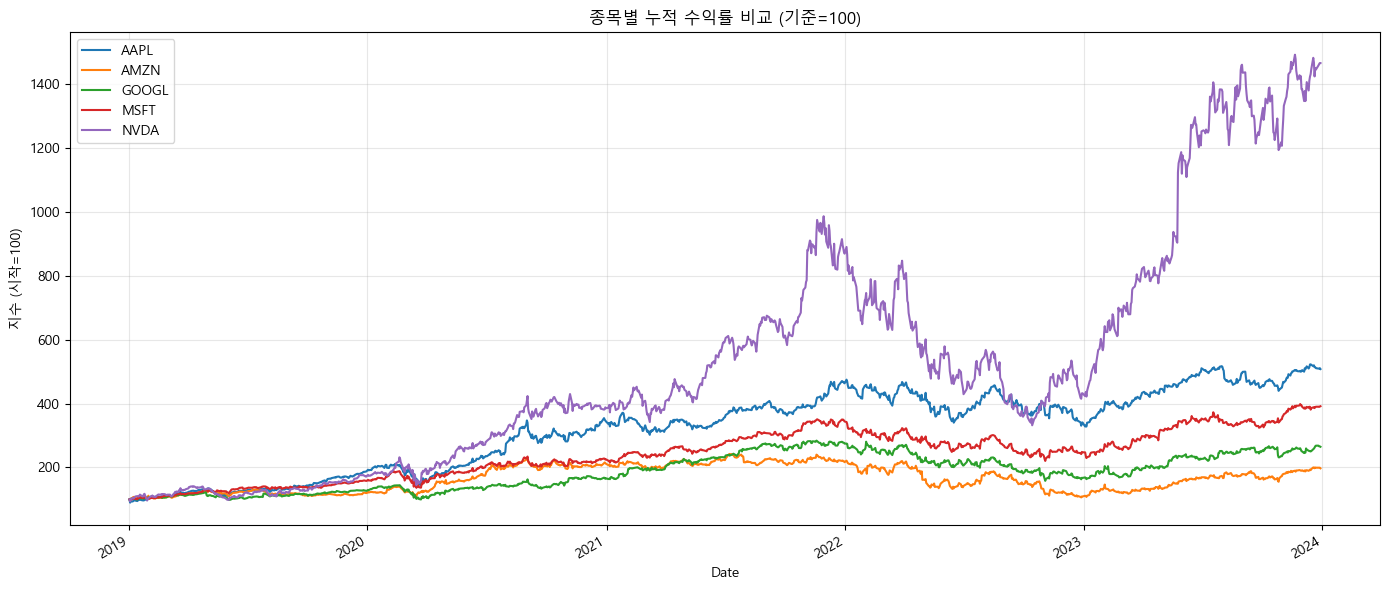

In [3]:
# 종목별 누적 수익률 비교 (정규화 = 첫날 기준 100)
normalized = close / close.iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 6))
for col in normalized.columns:
    normalized[col].plot(ax=ax, label=col, linewidth=1.5)

ax.set_title('종목별 누적 수익률 비교 (기준=100)')
ax.set_ylabel('지수 (시작=100)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 2. 멀티 자산 동시 백테스팅

vectorbt는 DataFrame을 입력으로 받아 **모든 종목을 한 번에** 백테스트할 수 있습니다.

In [4]:
# ─── 모든 종목에 골든크로스 전략 적용 ───────────────────────────────
fast_window = 20
slow_window = 60

fast_ma = close.rolling(fast_window).mean()
slow_ma = close.rolling(slow_window).mean()

# DataFrame 전체에 시그널 생성 (종목별로 독립적으로 계산)
entries_multi = (fast_ma >= slow_ma) & (fast_ma.shift(1) < slow_ma.shift(1))
exits_multi   = (fast_ma < slow_ma)  & (fast_ma.shift(1) >= slow_ma.shift(1))

# 멀티 자산 포트폴리오 (종목별 독립 전략)
pf_multi = vbt.Portfolio.from_signals(
    close, entries_multi, exits_multi,
    fees=0.001, slippage=0.001, freq='D',
    init_cash=100_000  # 종목당 $100,000
)

print('=== 종목별 성과 ===')
stats_df = pd.DataFrame({
    '총수익률': pf_multi.total_return(),
    '연수익률': pf_multi.annualized_return(),
    '샤프비율': pf_multi.sharpe_ratio(),
    '최대낙폭': pf_multi.max_drawdown(),
    '거래횟수': pf_multi.trades.count(),
}).round(4)

stats_df['총수익률'] = stats_df['총수익률'].map('{:.2%}'.format)
stats_df['연수익률'] = stats_df['연수익률'].map('{:.2%}'.format)
stats_df['최대낙폭'] = stats_df['최대낙폭'].map('{:.2%}'.format)
print(stats_df.to_string())

=== 종목별 성과 ===
           총수익률    연수익률    샤프비율     최대낙폭  거래횟수
Ticker                                        
AAPL    151.86%  30.74%  1.1112  -21.63%    11
AMZN    -14.15%  -4.33% -0.0042  -52.90%    15
GOOGL    67.02%  16.05%  0.6916  -44.83%    11
MSFT     75.18%  17.67%  0.8417  -35.72%     8
NVDA    346.03%  54.31%  1.1297  -64.69%    10


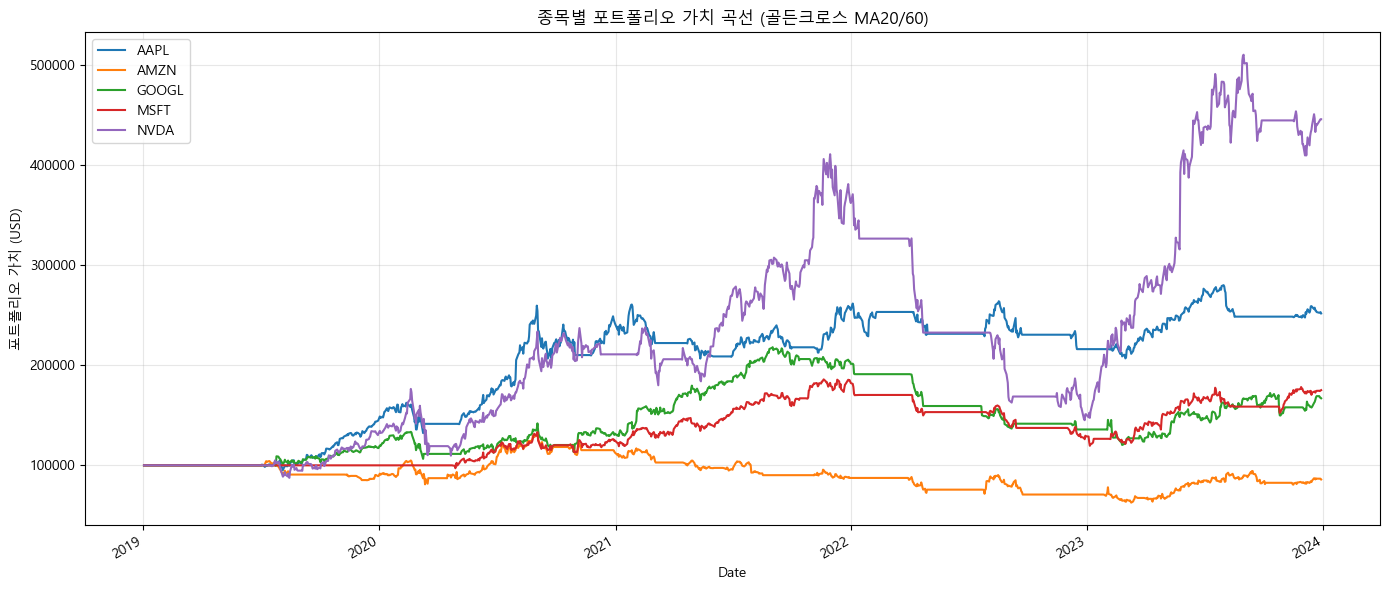

In [5]:
# 종목별 자산 곡선 비교
fig, ax = plt.subplots(figsize=(14, 6))

for col in close.columns:
    pf_multi.value()[col].plot(ax=ax, label=col, linewidth=1.5)

ax.set_title(f'종목별 포트폴리오 가치 곡선 (골든크로스 MA{fast_window}/{slow_window})')
ax.set_ylabel('포트폴리오 가치 (USD)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. 포트폴리오 비중 최적화

여러 자산을 합쳐서 포트폴리오를 구성할 때 **어떤 비중으로 배분**하느냐가 중요합니다.

### 대표적인 비중 배분 방법

| 방법 | 설명 | 특징 |
|-----|------|------|
| **균등 비중** | 모든 자산에 동일 비율 | 단순, 리밸런싱 필요 |
| **변동성 역비례** | 변동성 낮은 자산에 더 많은 비중 | 리스크 분산에 효과적 |
| **리스크 패리티** | 각 자산의 리스크 기여도 균등화 | 기관 투자자 선호 |

In [6]:
# ─── 일간 수익률 계산 ────────────────────────────────────────────
returns = close.pct_change().dropna()

print('=== 종목별 연간 변동성(Annualized Volatility) ===')
ann_vol = returns.std() * np.sqrt(252)
for ticker, vol in ann_vol.items():
    print(f'  {ticker}: {vol:.2%}')

=== 종목별 연간 변동성(Annualized Volatility) ===
  AAPL: 32.23%
  AMZN: 35.22%
  GOOGL: 31.81%
  MSFT: 30.49%
  NVDA: 51.77%


In [7]:
def equal_weight(n: int) -> np.ndarray:
    """균등 비중"""
    return np.ones(n) / n


def vol_inverse_weight(returns: pd.DataFrame, window: int = 60) -> pd.DataFrame:
    """
    변동성 역비례 비중
    - 최근 window일 변동성의 역수 비율로 비중 계산
    - 매일 업데이트 (rolling)
    """
    rolling_vol = returns.rolling(window).std()
    inv_vol = 1 / rolling_vol
    weights = inv_vol.div(inv_vol.sum(axis=1), axis=0)
    return weights.fillna(1 / len(returns.columns))


def risk_parity_weight(returns: pd.DataFrame) -> np.ndarray:
    """
    단순 리스크 패리티 (전체 기간 변동성 기준)
    """
    vol = returns.std()
    inv_vol = 1 / vol
    weights = inv_vol / inv_vol.sum()
    return weights.values


# 비중 계산
ew  = equal_weight(len(tickers))
rp  = risk_parity_weight(returns)
vw  = vol_inverse_weight(returns).iloc[-1].values  # 마지막 날 기준

weight_df = pd.DataFrame({
    '균등 비중': ew,
    '리스크 패리티': rp,
    '변동성 역비례': vw,
}, index=tickers)

print('=== 포트폴리오 비중 비교 ===')
print((weight_df * 100).round(1).to_string(), '%')

=== 포트폴리오 비중 비교 ===
       균등 비중  리스크 패리티  변동성 역비례
AAPL    20.0     21.7     29.9
MSFT    20.0     19.9     16.4
GOOGL   20.0     22.0     16.0
AMZN    20.0     22.9     23.8
NVDA    20.0     13.5     14.0 %


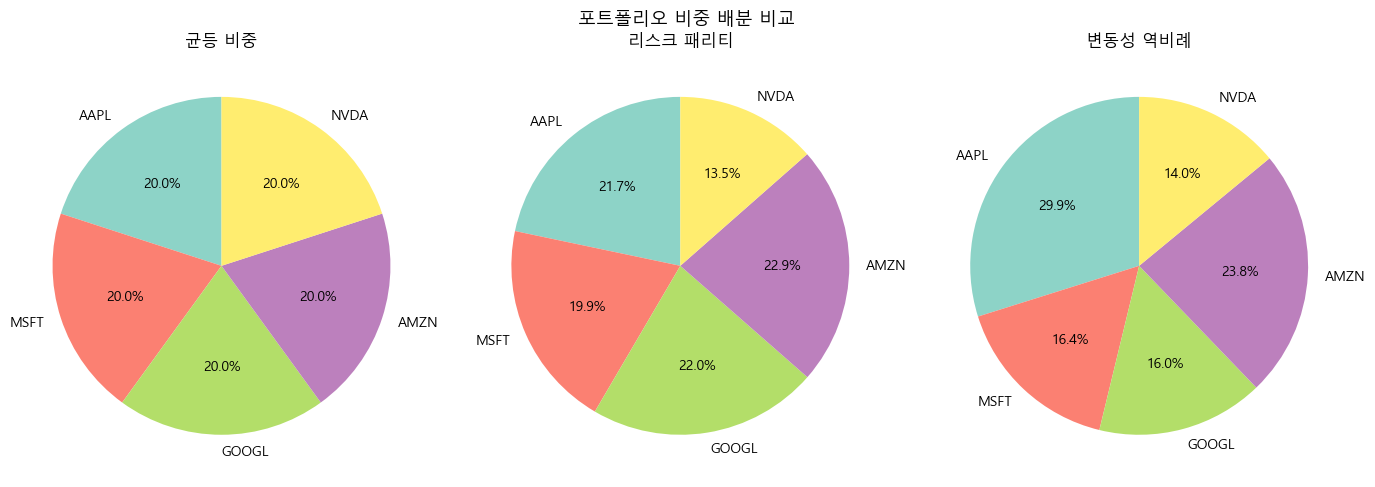

In [8]:
# 비중 시각화
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = plt.cm.Set3(np.linspace(0, 1, len(tickers)))

titles = ['균등 비중', '리스크 패리티', '변동성 역비례']
weights_list = [ew, rp, vw]

for ax, title, w in zip(axes, titles, weights_list):
    ax.pie(w, labels=tickers, colors=colors, autopct='%.1f%%',
           startangle=90)
    ax.set_title(title)

plt.suptitle('포트폴리오 비중 배분 비교', fontsize=13)
plt.tight_layout()
plt.show()

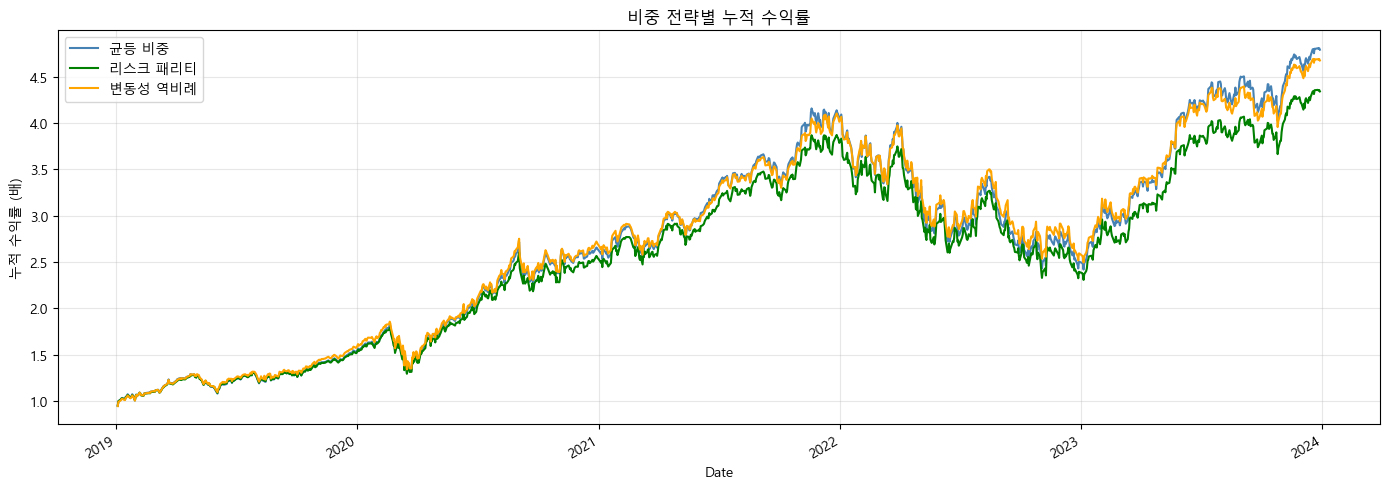

=== 비중 전략 성과 비교 ===
균등 비중        | 총수익률: 378.97% | 연수익률: 36.29% | 샤프: 1.16 | MDD: -41.83%
리스크 패리티      | 총수익률: 333.97% | 연수익률: 33.98% | 샤프: 1.13 | MDD: -40.40%
변동성 역비례      | 총수익률: 367.36% | 연수익률: 35.50% | 샤프: 1.18 | MDD: -39.20%


In [9]:
# ─── 비중별 백테스트 비교 ─────────────────────────────────────────
def weighted_portfolio_returns(close: pd.DataFrame, weights: np.ndarray) -> pd.Series:
    """고정 비중 포트폴리오 수익률 계산 (월간 리밸런싱)"""
    daily_ret = close.pct_change().dropna()
    port_ret  = (daily_ret * weights).sum(axis=1)
    return port_ret


ret_ew  = weighted_portfolio_returns(close, ew)
ret_rp  = weighted_portfolio_returns(close, rp)
ret_vw  = weighted_portfolio_returns(close, vw)

# 누적 수익률
cum_ew  = (1 + ret_ew).cumprod()
cum_rp  = (1 + ret_rp).cumprod()
cum_vw  = (1 + ret_vw).cumprod()

fig, ax = plt.subplots(figsize=(14, 5))
cum_ew.plot(ax=ax, label='균등 비중',       color='steelblue', linewidth=1.5)
cum_rp.plot(ax=ax, label='리스크 패리티',   color='green',     linewidth=1.5)
cum_vw.plot(ax=ax, label='변동성 역비례',   color='orange',    linewidth=1.5)

ax.set_title('비중 전략별 누적 수익률')
ax.set_ylabel('누적 수익률 (배)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 성과 요약
print('=== 비중 전략 성과 비교 ===')
for name, ret in [('균등 비중', ret_ew), ('리스크 패리티', ret_rp), ('변동성 역비례', ret_vw)]:
    ann_ret = ret.mean() * 252
    ann_std = ret.std() * np.sqrt(252)
    sharpe  = ann_ret / ann_std
    cumret  = (1 + ret).prod() - 1
    mdd     = ((1 + ret).cumprod() / (1 + ret).cumprod().cummax() - 1).min()
    print(f'{name:12} | 총수익률: {cumret:.2%} | 연수익률: {ann_ret:.2%} | 샤프: {sharpe:.2f} | MDD: {mdd:.2%}')

---
## 4. 자산 모멘텀 로테이션 전략

### 개념
- **모멘텀**: 최근 수익률이 좋은 자산이 앞으로도 좋을 가능성이 높다는 가설
- **로테이션**: 매달 최고 모멘텀 자산으로 교체 투자

```
매월 말:
  1. 모든 자산의 최근 N개월 수익률 계산
  2. 상위 K개 자산 선정
  3. 다음 달에 선정된 자산을 균등하게 투자
```

In [ ]:
def momentum_rotation(
    close: pd.DataFrame,
    lookback_months: int = 3,
    top_k: int = 2,
) -> pd.Series:
    """
    모멘텀 로테이션 전략

    매월 말: lookback_months 동안의 수익률 상위 top_k 자산 선택
    다음 달: 선택 자산을 균등 비중으로 투자
    """
    daily_ret = close.pct_change()
    # 월말 리샘플링 (pandas 1.x: 'M', pandas 2.2+: 'ME')
    monthly_close = close.resample('M').last()

    portfolio_returns = []
    portfolio_dates   = []

    for i in range(lookback_months, len(monthly_close) - 1):
        # 현재 월 기준 lookback 기간 수익률
        momentum = (
            monthly_close.iloc[i] / monthly_close.iloc[i - lookback_months] - 1
        )
        # 상위 top_k 자산 선택
        top_assets = momentum.nlargest(top_k).index.tolist()

        # 다음 달 실제 일간 수익률 집계
        next_month_start = monthly_close.index[i]
        next_month_end   = monthly_close.index[i + 1]

        mask = (daily_ret.index > next_month_start) & (daily_ret.index <= next_month_end)
        period_ret = daily_ret.loc[mask, top_assets]

        if len(period_ret) == 0:
            continue

        # 균등 비중 적용
        port_daily = period_ret.mean(axis=1)
        portfolio_returns.extend(port_daily.tolist())
        portfolio_dates.extend(port_daily.index.tolist())

    result = pd.Series(portfolio_returns, index=portfolio_dates, name='momentum_rotation')
    return result


# 여러 lookback 기간 테스트
fig, ax = plt.subplots(figsize=(14, 6))

# Buy & Hold (균등 비중) 벤치마크
bh_ret = weighted_portfolio_returns(close, ew)
(1 + bh_ret).cumprod().plot(ax=ax, label='Buy&Hold 균등', linestyle='--', color='gray', linewidth=1.5)

colors_list = ['steelblue', 'green', 'orange', 'purple']
for lb, color in zip([1, 3, 6, 12], colors_list):
    try:
        mom_ret = momentum_rotation(close, lookback_months=lb, top_k=2)
        cum_mom = (1 + mom_ret).cumprod()
        cum_mom.plot(ax=ax, label=f'모멘텀 {lb}개월', color=color, linewidth=1.5)
        total = cum_mom.iloc[-1] - 1
        print(f'모멘텀 lookback={lb}개월: 총수익률 {total:.2%}')
    except Exception as e:
        print(f'lookback={lb}: 오류 ({e})')

ax.set_title('자산 모멘텀 로테이션 전략 비교 (Top-2 자산 선택)')
ax.set_ylabel('누적 수익률 (배)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. 나만의 전략 라이브러리 구축

지금까지 배운 전략들을 **모듈로 구조화**하면 재사용과 관리가 쉬워집니다.

```
study_vectorbt/
  ├── utils/
  │    ├── data_loader.py    ← 데이터 로딩 공통 함수
  │    └── __init__.py
  ├── strategies/
  │    ├── golden_cross.py   ← 골든크로스 전략
  │    ├── rsi_strategy.py   ← RSI 전략
  │    ├── macd_strategy.py  ← MACD 전략
  │    └── __init__.py
  └── 05_실전_확장.ipynb
```

In [11]:
import sys, os
sys.path.insert(0, os.path.abspath("."))

# 전략 모듈 임포트
from vbt_backtest.strategies.golden_cross import run_backtest as gc_bt
from vbt_backtest.strategies.rsi_strategy  import run_backtest as rsi_bt
from vbt_backtest.strategies.macd_strategy import run_backtest as macd_bt
from vbt_backtest.data                     import load_close

print('모듈 임포트 성공!')

모듈 임포트 성공!


In [12]:
# ─── 전략 비교 프레임워크 ─────────────────────────────────────────
def compare_strategies(
    close: pd.Series,
    strategies: dict,
) -> pd.DataFrame:
    """
    여러 전략을 동시에 실행하고 성과를 비교하는 유틸리티

    Parameters
    ----------
    close      : 종가 시리즈
    strategies : {전략이름: 포트폴리오 객체} 딕셔너리
    """
    rows = []
    for name, pf in strategies.items():
        rows.append({
            '전략': name,
            '총수익률': f"{pf.total_return():.2%}",
            '연수익률': f"{pf.annualized_return():.2%}",
            '샤프비율': f"{pf.sharpe_ratio():.2f}",
            '소르티노': f"{pf.sortino_ratio():.2f}",
            '최대낙폭': f"{pf.max_drawdown():.2%}",
            '거래횟수': pf.trades.count(),
            '승률': f"{pf.trades.win_rate():.2%}",
        })
    return pd.DataFrame(rows).set_index('전략')


# load_close 유틸리티로 AAPL 단일 종목 로드 (멀티 자산 DataFrame 과 별개)
aapl_close = load_close('AAPL', start='2019-01-01', end='2023-12-31')

# Buy & Hold 벤치마크
bh_e = pd.Series(False, index=aapl_close.index); bh_e.iloc[0] = True
bh_x = pd.Series(False, index=aapl_close.index); bh_x.iloc[-1] = True
pf_bh = vbt.Portfolio.from_signals(aapl_close, bh_e, bh_x, fees=0.001, freq='D')

strategies_map = {
    'Buy & Hold':     pf_bh,
    '골든크로스 MA20/60': gc_bt(aapl_close, 20, 60),
    '골든크로스 MA10/30': gc_bt(aapl_close, 10, 30),
    'RSI(14, 30/70)': rsi_bt(aapl_close),
    'MACD(12/26/9)':  macd_bt(aapl_close),
}

result_df = compare_strategies(aapl_close, strategies_map)
print('=== AAPL 전략 종합 비교 ===')
print(result_df.to_string())

=== AAPL 전략 종합 비교 ===
                   총수익률    연수익률  샤프비율  소르티노     최대낙폭  거래횟수       승률
전략                                                                 
Buy & Hold      407.07%  60.17%  1.41  2.08  -31.43%     1  100.00%
골든크로스 MA20/60   151.86%  30.74%  1.11  1.66  -21.63%    11   63.64%
골든크로스 MA10/30   148.78%  30.27%  1.16  1.74  -31.34%    18   55.56%
RSI(14, 30/70)   89.56%  20.39%  0.87  1.29  -26.94%     5  100.00%
MACD(12/26/9)   271.79%  46.38%  1.75  2.79  -17.84%    44   52.27%


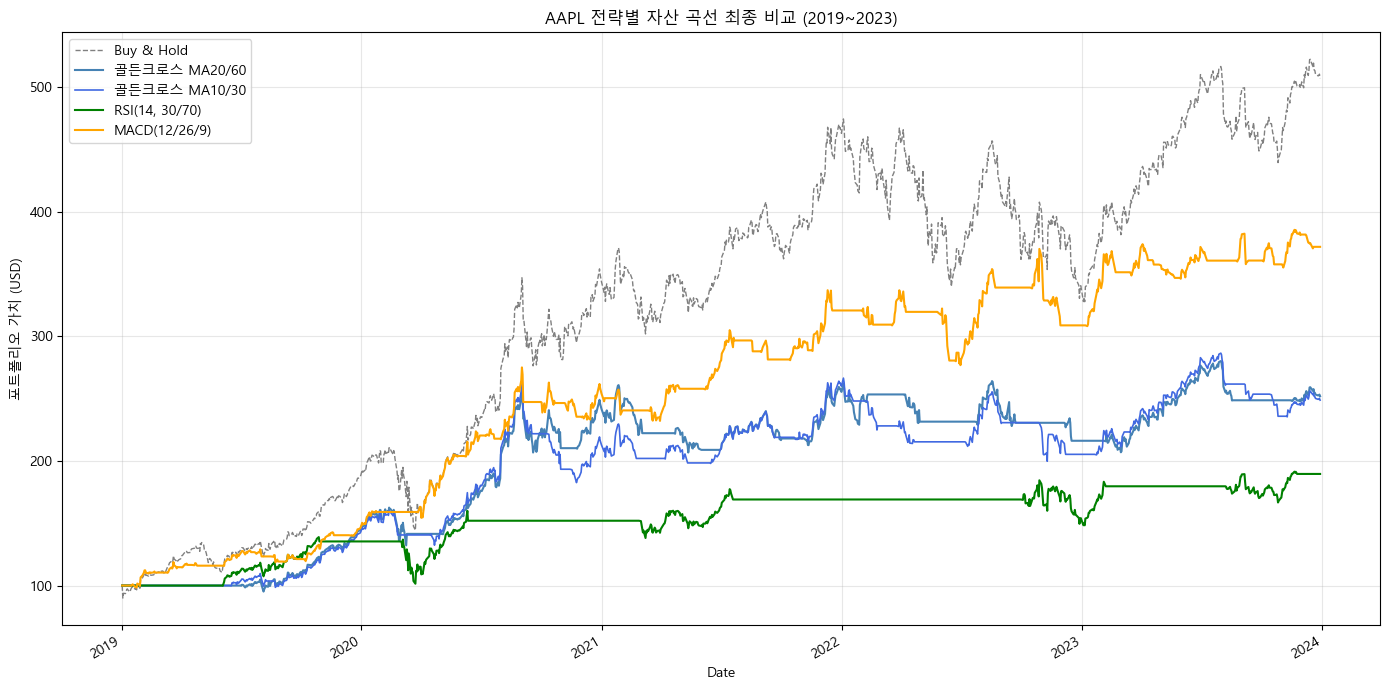

In [13]:
# 전체 자산 곡선 최종 비교
fig, ax = plt.subplots(figsize=(14, 7))

style_map = {
    'Buy & Hold':     ('gray',      '--', 1.0),
    '골든크로스 MA20/60': ('steelblue', '-',  1.5),
    '골든크로스 MA10/30': ('royalblue', '-',  1.2),
    'RSI(14, 30/70)': ('green',     '-',  1.5),
    'MACD(12/26/9)':  ('orange',    '-',  1.5),
}

for name, pf in strategies_map.items():
    color, ls, lw = style_map[name]
    pf.value().plot(ax=ax, label=name, color=color, linestyle=ls, linewidth=lw)

ax.set_title('AAPL 전략별 자산 곡선 최종 비교 (2019~2023)')
ax.set_ylabel('포트폴리오 가치 (USD)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. 전체 커리큘럼 마무리 정리

### 5단계에서 배운 핵심 내용

| 주제 | 핵심 내용 |
|-----|----------|
| **멀티 자산 백테스팅** | DataFrame 입력으로 종목별 독립 전략 동시 실행 |
| **균등 비중** | 단순하지만 강건한 기본 전략 |
| **변동성 역비례** | 변동성 낮은 자산에 더 많은 비중 → 리스크 분산 |
| **모멘텀 로테이션** | 최근 수익률 상위 자산으로 매월 교체 |
| **전략 라이브러리** | 모듈화 → 재사용·유지보수 편리 |

---
### 전체 학습 여정 요약

```
2단계: vectorbt 기초 → Portfolio.from_signals(), 시그널 개념
3단계: 전략 구현     → 골든크로스, RSI, MACD, 전략 조합
4단계: 성과 분석     → pf.stats(), 그리드서치, IS/OOS 검증, Walk-Forward
5단계: 실전 확장     → 멀티 자산, 비중 최적화, 모멘텀 로테이션, 모듈화
```

### 다음 단계로 나아가기

- **실시간 데이터 연동**: `ccxt`, `FinanceDataReader`, 증권사 API
- **머신러닝 신호**: 기술 지표를 Feature로 → 분류 모델로 매수·매도 예측
- **리스크 관리**: 포지션 사이징, 스톱로스, 켈리 공식
- **실전 매매 시스템**: 시그널 자동화, 주문 실행 연동